<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-1-Manifold-Learning/Untitled142.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Manifold learning: the upper hemisphere**


**Positions and velocities**
Below is a self-contained Keras script that:

1. Generates positions and tangent velocities on the upper unit sphere (with noise).

2. Builds the same autoencoder architecture as before.

3. Uses a custom training loop with a loss that has:

position reconstruction term, velocity consistency term (using the decoder Jacobian and least-squares projection).

4. Tracks training and test losses.



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_q (InputLayer)            │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690 (2.70 KB)

 Trainable params: 690 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xi (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recon_q (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691 (2.70 KB)

 Trainable params: 691 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch    0 | train loss = 1.2985e+00 | test loss = 1.1749e+00
Epoch   10 | train loss = 1.7034e-01 | test loss = 1.5088e-01
Epoch   20 | train loss = 9.0604e-02 | test loss = 8.8322e-02
Epoch   30 | train loss = 8.2015e-02 | test loss = 7.9618e-02
Epoch   40 | train loss = 7.2024e-02 | test loss = 7.1736e-02
Epoch   50 | train loss = 6.6146e-02 | test loss = 6.6088e-02
Epoch   60 | train loss = 6.2752e-02 | test loss = 6.1579e-02
Epoch   70 | train loss = 5.9411e-02 | test loss = 5.8515e-02
Epoch   80 | train loss = 5.5678e-02 | test loss = 5.6685e-02
Epoch   90 | train loss = 5.5469e-02 | test loss = 5.5095e-02
Epoch  100 | train loss = 5.3110e-02 | test loss = 5.3272e-02
Epoch  110 | train loss = 5.1983e-02 | test loss = 5.1519e-02
Epoch  120 | train loss = 5.0647e-02 | test loss = 5.1123e-02
Epoch  130 | train loss = 5.0638e-02 | test loss = 4.9457e-02
Epoch  140 | train loss = 4.8129e-02 | test loss = 4.8502e-02
Epoch  150 | train loss = 4.7912e-02 | test loss = 4.9887e-02
Epoch  1

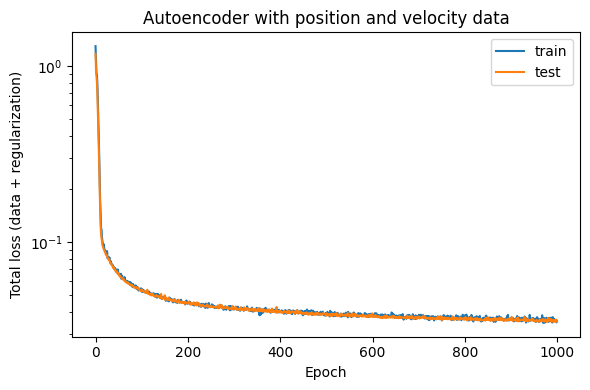

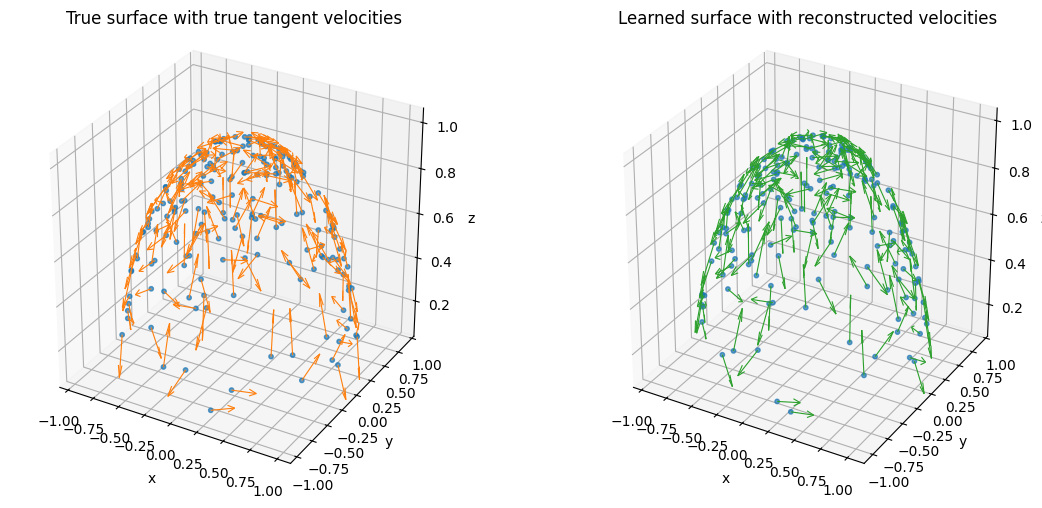

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (for 3D plots)

# ==========================================
# 0. Reproducibility
# ==========================================
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 1. Generate positions + velocities on upper sphere
# ==========================================

N = 1000   # dataset size

# Sample latent points uniformly in unit disk U in R^2
r = np.sqrt(np.random.rand(N))
theta = 2 * np.pi * np.random.rand(N)

xi1 = r * np.cos(theta)
xi2 = r * np.sin(theta)

# True embedding: upper hemisphere
z = np.sqrt(1.0 - (xi1**2 + xi2**2))
Q_true = np.stack([xi1, xi2, z], axis=1)   # shape (N,3)

# Sample random velocities in R^3 and project to tangent space at q
W = np.random.randn(N, 3)
dotWq = np.sum(W * Q_true, axis=1, keepdims=True)
V_true = W - dotWq * Q_true  # tangent component

# Normalize tangent velocities
V_norm = np.linalg.norm(V_true, axis=1, keepdims=True) + 1e-8
V_true = V_true / V_norm

# Add 5% Gaussian noise to positions and velocities
noise_level = 0.05
Q_noisy = Q_true + noise_level * np.random.randn(*Q_true.shape)
V_noisy = V_true + noise_level * np.random.randn(*V_true.shape)

# ==========================================
# 2. Train / test split (80/20)
# ==========================================

N_train = int(0.8 * N)
indices = np.random.permutation(N)

train_idx = indices[:N_train]
test_idx  = indices[N_train:]

Q_train = Q_noisy[train_idx]
V_train = V_noisy[train_idx]

Q_test  = Q_noisy[test_idx]
V_test  = V_noisy[test_idx]

# Convert to tensors
Q_train_tf = tf.constant(Q_train, dtype=tf.float32)
V_train_tf = tf.constant(V_train, dtype=tf.float32)

Q_test_tf  = tf.constant(Q_test, dtype=tf.float32)
V_test_tf  = tf.constant(V_test, dtype=tf.float32)

# ==========================================
# 3. Define encoder and decoder
# ==========================================

reg = regularizers.l2(1e-3)

# Encoder: R^3 -> R^2
input_q = keras.Input(shape=(3,), name="input_q")
x = layers.Dense(32, activation="swish", kernel_regularizer=reg)(input_q)
x = layers.Dense(16, activation="swish", kernel_regularizer=reg)(x)
latent = layers.Dense(2, activation="linear", kernel_regularizer=reg,
                      name="latent")(x)
encoder = keras.Model(input_q, latent, name="encoder")

# Decoder: R^2 -> R^3
input_xi = keras.Input(shape=(2,), name="input_xi")
y = layers.Dense(16, activation="swish", kernel_regularizer=reg)(input_xi)
y = layers.Dense(32, activation="swish", kernel_regularizer=reg)(y)
output_q = layers.Dense(3, activation="linear", kernel_regularizer=reg,
                        name="recon_q")(y)
decoder = keras.Model(input_xi, output_q, name="decoder")

optimizer = keras.optimizers.Adam(1e-3)

encoder.summary()
decoder.summary()

# ==========================================
# 4. Velocity reconstruction via decoder Jacobian
# ==========================================

@tf.function(reduce_retracing=True)
def reconstruct_velocity(q_batch, v_batch):
    """
    Given a batch of positions q (B,3) and tangent velocities v (B,3),
    compute reconstructed velocities v_hat using the decoder geometry:

    1. xi = encoder(q)
    2. X1, X2 = ∂Φ/∂xi^1, ∂Φ/∂xi^2  (3D tangent frame)
    3. Solve least-squares v ≈ a1 X1 + a2 X2
    4. Return v_hat = X @ a
    """
    xi = encoder(q_batch)  # (B,2)

    def single_sample(xi_i, v_i):
        with tf.GradientTape() as tape:
            tape.watch(xi_i)
            q_i = decoder(tf.reshape(xi_i, (1, 2)))  # (1,3)
            q_i = tf.reshape(q_i, (3,))             # (3,)
        # Jacobian: (3,2)
        J = tape.jacobian(q_i, xi_i)
        X1 = J[:, 0]   # (3,)
        X2 = J[:, 1]   # (3,)
        X  = tf.stack([X1, X2], axis=1)  # (3,2)

        # Least-squares: minimize ||X a - v||^2
        XtX = tf.matmul(X, X, transpose_a=True)  # (2,2)
        Xtv = tf.matmul(X, tf.reshape(v_i, (3,1)), transpose_a=True)  # (2,1)
        XtX_reg = XtX + 1e-6 * tf.eye(2)
        a = tf.linalg.solve(XtX_reg, Xtv)  # (2,1)
        v_hat = tf.matmul(X, a)           # (3,1)
        return tf.reshape(v_hat, (3,))

    v_hat_list = tf.map_fn(
        lambda args: single_sample(args[0], args[1]),
        (xi, v_batch),
        dtype=tf.float32
    )
    return v_hat_list  # (B,3)

# ==========================================
# 5. Custom training loop (positions + velocities)
# ==========================================

epochs = 1000
batch_size = 32
vel_subset_size = 8   # subset per batch for velocity loss

train_losses = []
test_losses  = []

num_batches = int(np.ceil(N_train / batch_size))

for epoch in range(epochs):
    # Shuffle training data each epoch
    idx = np.random.permutation(N_train)
    Q_train_sh = tf.gather(Q_train_tf, idx)
    V_train_sh = tf.gather(V_train_tf, idx)

    epoch_loss = 0.0

    for b in range(num_batches):
        start = b * batch_size
        end   = min((b+1) * batch_size, N_train)
        q_batch = Q_train_sh[start:end]
        v_batch = V_train_sh[start:end]

        with tf.GradientTape() as tape:
            # Position reconstruction for the whole batch
            xi_batch = encoder(q_batch)
            q_hat_batch = decoder(xi_batch)
            pos_loss = tf.reduce_mean(tf.reduce_sum(
                tf.square(q_hat_batch - q_batch), axis=1))

            # Velocity loss on a small random subset of the batch
            b_size = tf.shape(q_batch)[0]
            k = tf.minimum(vel_subset_size, b_size)
            sub_idx = tf.random.shuffle(tf.range(b_size))[:k]

            q_sub = tf.gather(q_batch, sub_idx)
            v_sub = tf.gather(v_batch, sub_idx)

            v_hat_sub = reconstruct_velocity(q_sub, v_sub)

            vel_loss = tf.reduce_mean(tf.reduce_sum(
                tf.square(v_hat_sub - v_sub), axis=1))

            # Data loss
            data_loss = pos_loss + vel_loss

            # Add L2 regularization losses (same as for test)
            reg_loss = 0.0
            if encoder.losses or decoder.losses:
                reg_loss = tf.add_n(encoder.losses + decoder.losses)

            total_loss = data_loss + reg_loss

        grads = tape.gradient(total_loss,
                              encoder.trainable_variables + decoder.trainable_variables)
        optimizer.apply_gradients(
            zip(grads, encoder.trainable_variables + decoder.trainable_variables)
        )

        epoch_loss += total_loss.numpy() * (end - start)

    epoch_loss /= N_train
    train_losses.append(epoch_loss)

    # -------- Test loss (no gradient) --------
    xi_test = encoder(Q_test_tf)
    q_hat_test = decoder(xi_test)
    pos_loss_test = tf.reduce_mean(tf.reduce_sum(
        tf.square(q_hat_test - Q_test_tf), axis=1))

    v_hat_test = reconstruct_velocity(Q_test_tf, V_test_tf)
    vel_loss_test = tf.reduce_mean(tf.reduce_sum(
        tf.square(v_hat_test - V_test_tf), axis=1))

    data_loss_test = pos_loss_test + vel_loss_test

    reg_loss_test = 0.0
    if encoder.losses or decoder.losses:
        reg_loss_test = tf.add_n(encoder.losses + decoder.losses)

    test_loss = data_loss_test + reg_loss_test
    test_losses.append(test_loss.numpy())

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d} | train loss = {epoch_loss:.4e} | test loss = {test_loss.numpy():.4e}")

# ==========================================
# 6. Plot training / test losses
# ==========================================

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total loss (data + regularization)")
plt.title("Autoencoder with position and velocity data")
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 7. Plot true and learned surfaces with velocities
# ==========================================

# Use a subset of test points for visualization
num_vis = 200
if len(Q_test) < num_vis:
    num_vis = len(Q_test)

vis_idx = np.random.choice(len(Q_test), size=num_vis, replace=False)

Q_true_vis = Q_true[test_idx][vis_idx]   # clean true positions
V_true_vis = V_true[test_idx][vis_idx]   # clean true velocities

Q_noisy_vis = Q_test[vis_idx]            # noisy positions (used as input)
V_noisy_vis = V_test[vis_idx]            # noisy velocities

# Learned reconstruction from noisy inputs
Q_noisy_vis_tf = tf.constant(Q_noisy_vis, dtype=tf.float32)
V_noisy_vis_tf = tf.constant(V_noisy_vis, dtype=tf.float32)

xi_vis = encoder(Q_noisy_vis_tf)
Q_learn_vis = decoder(xi_vis).numpy()               # reconstructed positions
V_learn_vis = reconstruct_velocity(Q_noisy_vis_tf,
                                   V_noisy_vis_tf).numpy()  # reconstructed velocities

# Scale velocities for visualization
vel_scale = 0.2
V_true_plot  = vel_scale * V_true_vis
V_learn_plot = vel_scale * V_learn_vis

fig = plt.figure(figsize=(12,5))

# --- True surface + true velocities ---
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(Q_true_vis[:,0], Q_true_vis[:,1], Q_true_vis[:,2],
            s=10, alpha=0.7, label="true points")
ax1.quiver(Q_true_vis[:,0], Q_true_vis[:,1], Q_true_vis[:,2],
           V_true_plot[:,0], V_true_plot[:,1], V_true_plot[:,2],
           length=1.0, normalize=False, linewidth=0.8, color="tab:orange")
ax1.set_title("True surface with true tangent velocities")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_box_aspect([1,1,1])

# --- Learned surface + learned velocities ---
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(Q_learn_vis[:,0], Q_learn_vis[:,1], Q_learn_vis[:,2],
            s=10, alpha=0.7, label="learned points")
ax2.quiver(Q_learn_vis[:,0], Q_learn_vis[:,1], Q_learn_vis[:,2],
           V_learn_plot[:,0], V_learn_plot[:,1], V_learn_plot[:,2],
           length=1.0, normalize=False, linewidth=0.8, color="tab:green")
ax2.set_title("Learned surface with reconstructed velocities")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


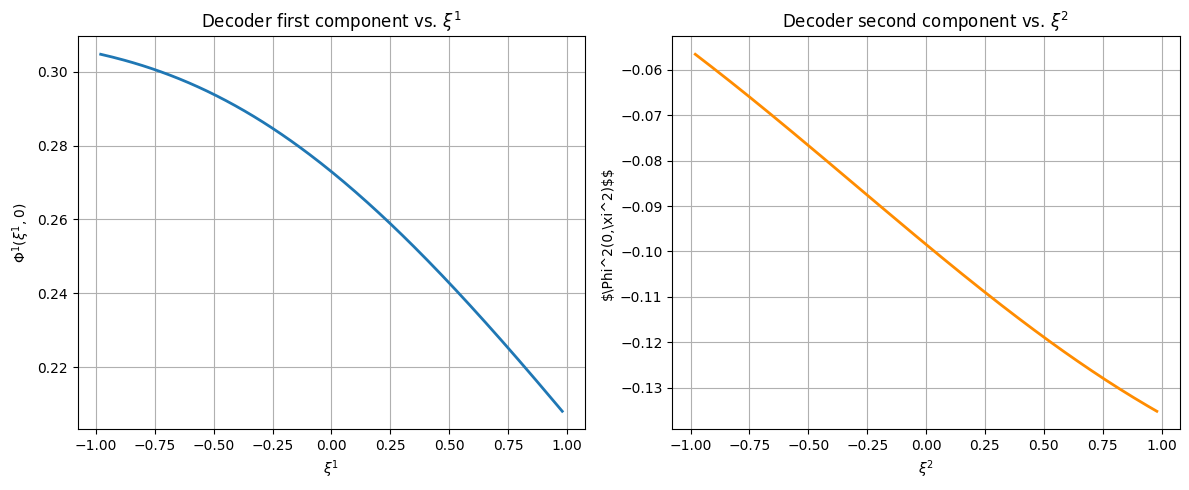

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Assume the trained decoder model is already defined:
# decoder: R^2 → R^3
# ---------------------------------------------------

# 1. Define latent coordinate lines for plotting
num_points = 200
xi1_line = np.linspace(-0.98, 0.98, num_points)
xi2_line = np.linspace(-0.98, 0.98, num_points)

# Points along xi = (xi1, 0)
xi1_inputs = np.stack([xi1_line, np.zeros_like(xi1_line)], axis=1)

# Points along xi = (0, xi2)
xi2_inputs = np.stack([np.zeros_like(xi2_line), xi2_line], axis=1)

# ---------------------------------------------------
# 2. Evaluate decoder along these 1D slices
# ---------------------------------------------------

q_from_xi1 = decoder.predict(xi1_inputs)
q_from_xi2 = decoder.predict(xi2_inputs)

# Extract components
Phi1_xi1 = q_from_xi1[:, 0]   # first output component
Phi2_xi2 = q_from_xi2[:, 1]   # second output component

# ---------------------------------------------------
# 3. Plot results
# ---------------------------------------------------

plt.figure(figsize=(12,5))

# --- Plot (1) Decoder component Φ^1(ξ¹,0) ---
plt.subplot(1,2,1)
plt.plot(xi1_line, Phi1_xi1, linewidth=2)
plt.xlabel(r"$\xi^1$")
plt.ylabel(r"$\Phi^1(\xi^1,0)$")
plt.title(r"Decoder first component vs. $\xi^1$")
plt.grid(True)

# --- Plot (2) Decoder component Φ^2(0,ξ²) ---
plt.subplot(1,2,2)
plt.plot(xi2_line, Phi2_xi2, linewidth=2, color="darkorange")
plt.xlabel(r"$\xi^2$")
plt.ylabel(r"$\Phi^2(0,\xi^2)$$")
plt.title(r"Decoder second component vs. $\xi^2$")
plt.grid(True)


plt.tight_layout()
plt.show()


Next is  a Keras/TensorFlow snippet that does the following:

1. samples a few  $\xi$  points in the unit disk,

2. computes the learned normal from your trained decoder,

3. computes the true normal analytically,

4. evaluates the angle and provides a table.

In [ ]:
import numpy as np
import tensorflow as tf

# Assume: trained decoder model exists: decoder : R^2 -> R^3

def learned_normal_and_point(xi):
    """
    Given xi in R^2, compute:
    - q_learned = Phi_theta(xi)
    - n_learned = dPhi/dxi1 x dPhi/dxi2 at xi
    """
    xi = tf.convert_to_tensor(xi, dtype=tf.float32)  # shape (2,)
    with tf.GradientTape() as tape:
        tape.watch(xi)
        q = decoder(tf.reshape(xi, (1, 2)))  # (1,3)
        q = tf.reshape(q, (3,))             # (3,)
    J = tape.jacobian(q, xi)                # (3,2)
    X1 = J[:, 0]
    X2 = J[:, 1]
    n_learned = tf.linalg.cross(X1, X2)     # (3,)
    return q, n_learned

def angle_between_normals_at_learned_point(xi):
    xi = tf.convert_to_tensor(xi, dtype=tf.float32)
    q_learned, n_learn = learned_normal_and_point(xi)

    # true radial normal at the learned point
    n_true = q_learned / (tf.norm(q_learned) + 1e-8)

    dot = tf.tensordot(n_true, n_learn, axes=1)
    norm_true = tf.norm(n_true)
    norm_learn = tf.norm(n_learn)

    # use absolute value to ignore orientation
    cos_theta = tf.abs(dot) / (norm_true * norm_learn + 1e-8)
    cos_theta = tf.clip_by_value(cos_theta, -1.0, 1.0)
    theta = tf.acos(cos_theta)
    return theta


# ---------------------------------------------------
# Sample a few xi in the unit disk and compute angles
# ---------------------------------------------------

num_samples = 10
angles_rad = []
angles_deg = []
xis = []

np.random.seed(0)
for _ in range(num_samples):
    # sample uniformly in the unit disk
    r = np.sqrt(np.random.rand())
    th = 2 * np.pi * np.random.rand()
    xi1 = r * np.cos(th)
    xi2 = r * np.sin(th)
    xi = np.array([xi1, xi2], dtype=np.float32)

    theta = angle_between_normals_at_learned_point(xi).numpy()
    angles_rad.append(theta)
    angles_deg.append(theta * 180.0 / np.pi)
    xis.append(xi)

print("ξ^1      ξ^2      angle (rad)   angle (deg)")
for xi, th_r, th_d in zip(xis, angles_rad, angles_deg):
    print(f"{xi[0]: .4f}  {xi[1]: .4f}   {th_r: .6f}    {th_d: .3f}")


ξ^1      ξ^2      angle (rad)   angle (deg)
-0.1607  -0.7232    0.016872     0.967
-0.7457  -0.2161    0.013995     0.802
-0.3960  -0.5165    0.013084     0.750
 0.5144  -0.4160    0.014879     0.852
-0.7300   0.6564    0.021695     1.243
-0.8752  -0.1607    0.014244     0.816
 0.6728  -0.3396    0.012629     0.724
 0.2276   0.1387    0.016566     0.949
 0.0705  -0.1235    0.023839     1.366
 0.6039  -0.6430    0.028500     1.633
